In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import json
import pathlib
from scipy.signal import welch
from src.environment.atmosphere import Atmosphere
from src.models.dual_rotor_beam_drone import DualRotorBeamDrone
from src.models.base import State
from src.environment.dryden_wind import DrydenConfig, DrydenWindGenerator
from src.controllers.pid import PIDController
from src.sensors.angle_sensor import AngleSensor

In [39]:
with open("simulations/1d_suspended_beam_drone/config.json", "r", encoding="utf-8") as file:
    config = json.load(file)

with open("simulations/1d_suspended_beam_drone/ziegler_nichols_pid_constants.json", "r", encoding="utf-8") as file:
    pid_constants = json.load(file)

In [40]:
time_min = 2.0 # min
dt = config["simulation"]["dt"]
total_steps = int(time_min * 60.0 / dt)

In [41]:
dryden_wind_config = DrydenConfig(
    mean_velocity=config["dryden"]["mean_velocity"],
    sigma_w=config["dryden"]["sigma_w"],
    length_scale_Lw=config["dryden"]["length_scale_Lw"],
    nominal_airspeed_V=config["dryden"]["nominal_airspeed_V"]
)
wind_generator = DrydenWindGenerator(dryden_wind_config, dt=dt)
wind_velocities = wind_generator.generate_wind(num_steps=total_steps, channels=2, seed=int(config["dryden"]["seed"]))
v_wind_left, v_wind_right = wind_velocities[:, 0], wind_velocities[:, 1]

In [42]:
target_angle = 0.0

drone = DualRotorBeamDrone(
    mass=config["drone"]["mass"],
    length=config["drone"]["length"],
    width=config["drone"]["width"],
    motor_base_thrust=config["drone"]["motor_base_thrust"],
    max_motor_thrust=config["drone"]["max_motor_thrust"],
    angular_damping=config["drone"]["angular_damping"]
)

initial_angle_deg = -15.6
initial_angle = np.radians(initial_angle_deg)
drone.state.angle

0.0

In [43]:
angle_sensor = AngleSensor(noise_std=0.001)
def run_sim(kp: float = 0.0, ki: float = 0.0, kd: float = 0.0, v_wind_left=None, v_wind_right=None):
    angle_history = []
    pid_controller = PIDController(kp=kp, ki=ki, kd=kd, dt=dt)

    for step in range(total_steps):
        current_angle = angle_sensor.read(drone.state.angle, dt)
        pid_output = pid_controller.compute(setpoint=target_angle, measured_value=current_angle)
        if v_wind_left is None and v_wind_right is None:
            drone.step(pid_output=pid_output)
        else:
            drone.step(pid_output=pid_output, v_wind_left=v_wind_left[step], v_wind_right=v_wind_right[step])

        angle_history.append(drone.state.angle)
    return angle_history


In [44]:
# Simulation mode
sim_mode = ["wind", "no_wind"]

In [45]:

sim_result = {}
for key, values in pid_constants.items():
    sim_result[key] = {}
    for mode in sim_mode:
        angle_history = []
        drone.reset(State(angle=initial_angle, angular_velocity=0.0))
        print(f"Initial Angle: {np.rad2deg(drone.state.angle)}, PID Constants: {key}, Mode: {mode}")
        if mode == "wind":
            angle_history = run_sim(kp=values["kp"], ki=values["ki"], kd=values["kd"], v_wind_left=v_wind_left, v_wind_right=v_wind_right)
        elif mode == "no_wind":
            angle_history = run_sim(kp=values["kp"], ki=values["ki"], kd=values["kd"])

        sim_result[key][mode] = angle_history

Initial Angle: -15.6, PID Constants: classic, Mode: wind
Initial Angle: -15.6, PID Constants: classic, Mode: no_wind
Initial Angle: -15.6, PID Constants: p, Mode: wind
Initial Angle: -15.6, PID Constants: p, Mode: no_wind
Initial Angle: -15.6, PID Constants: pi, Mode: wind
Initial Angle: -15.6, PID Constants: pi, Mode: no_wind
Initial Angle: -15.6, PID Constants: pd, Mode: wind
Initial Angle: -15.6, PID Constants: pd, Mode: no_wind
Initial Angle: -15.6, PID Constants: pessen, Mode: wind
Initial Angle: -15.6, PID Constants: pessen, Mode: no_wind
Initial Angle: -15.6, PID Constants: some_overshoot, Mode: wind
Initial Angle: -15.6, PID Constants: some_overshoot, Mode: no_wind
Initial Angle: -15.6, PID Constants: no_overshoot, Mode: wind
Initial Angle: -15.6, PID Constants: no_overshoot, Mode: no_wind


In [46]:
target_history = np.full(total_steps, target_angle)
time_history = np.arange(total_steps) * dt

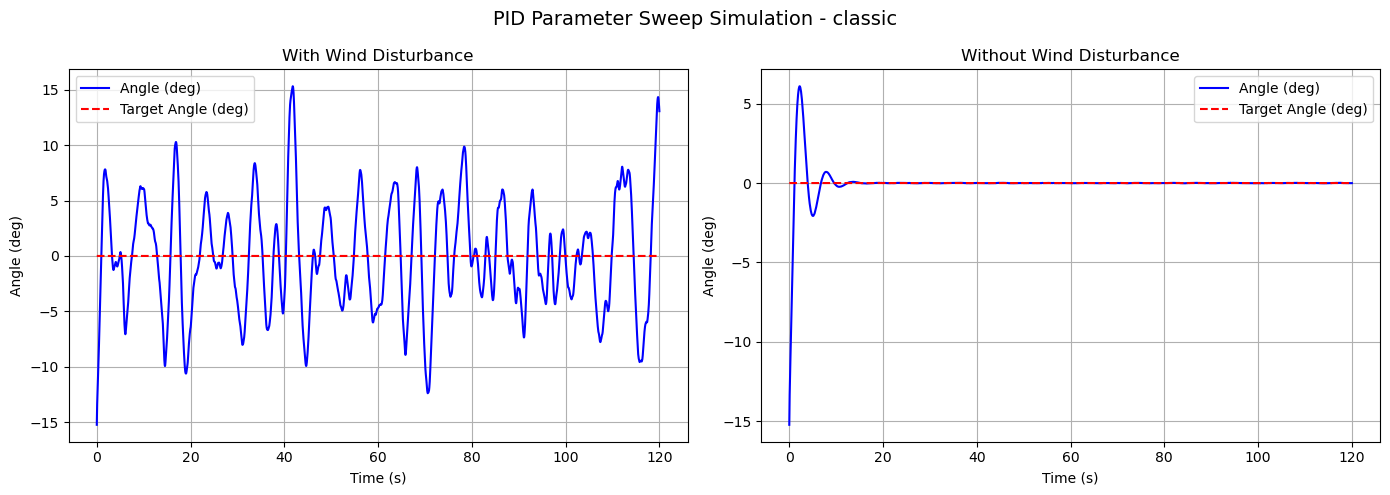

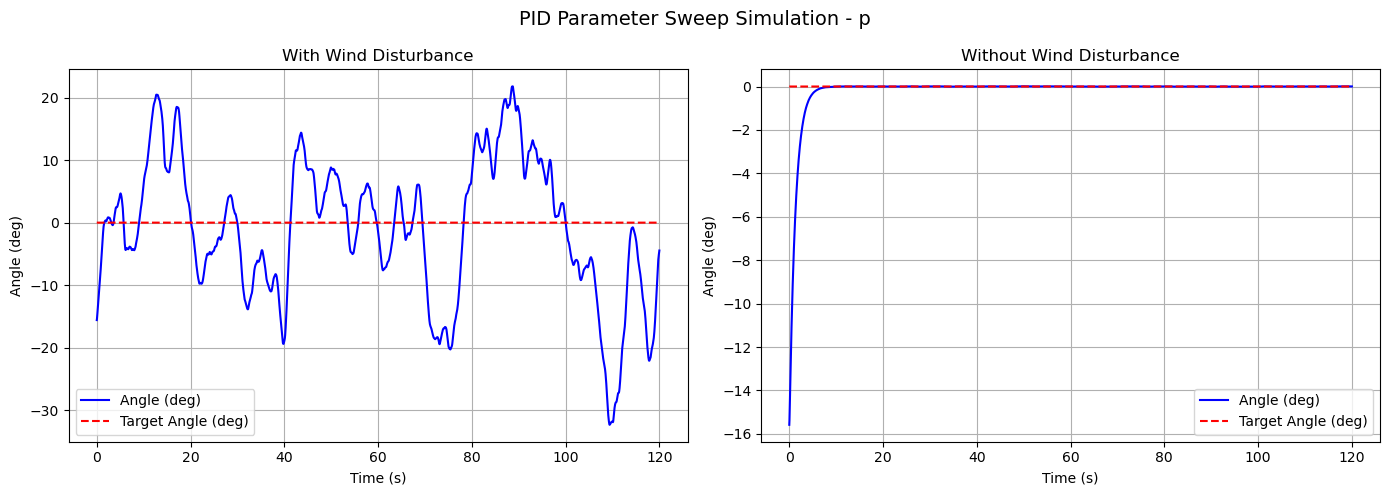

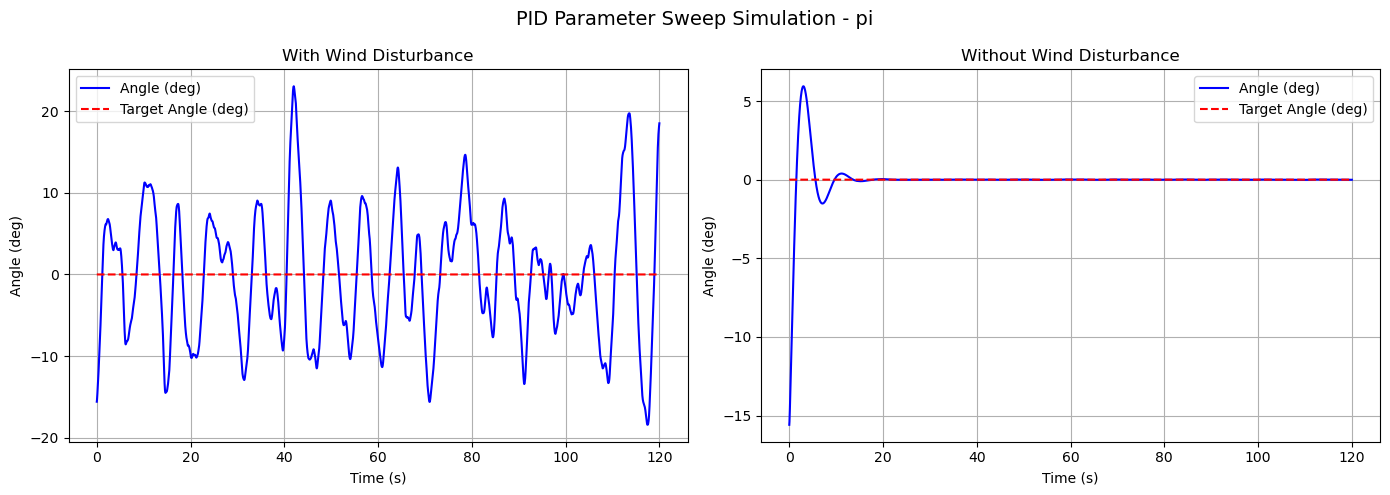

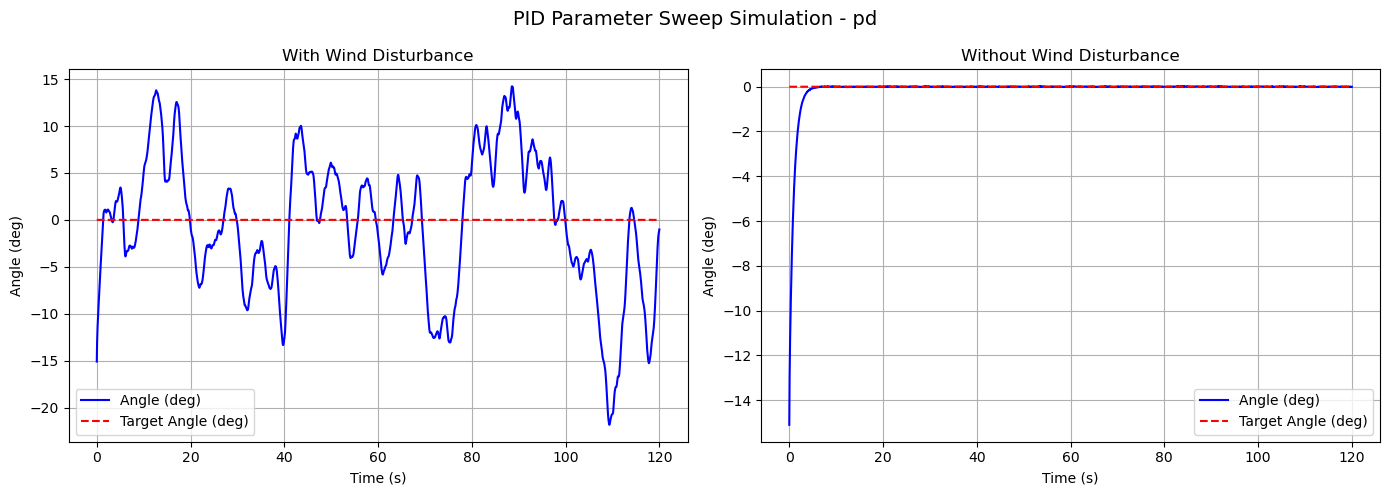

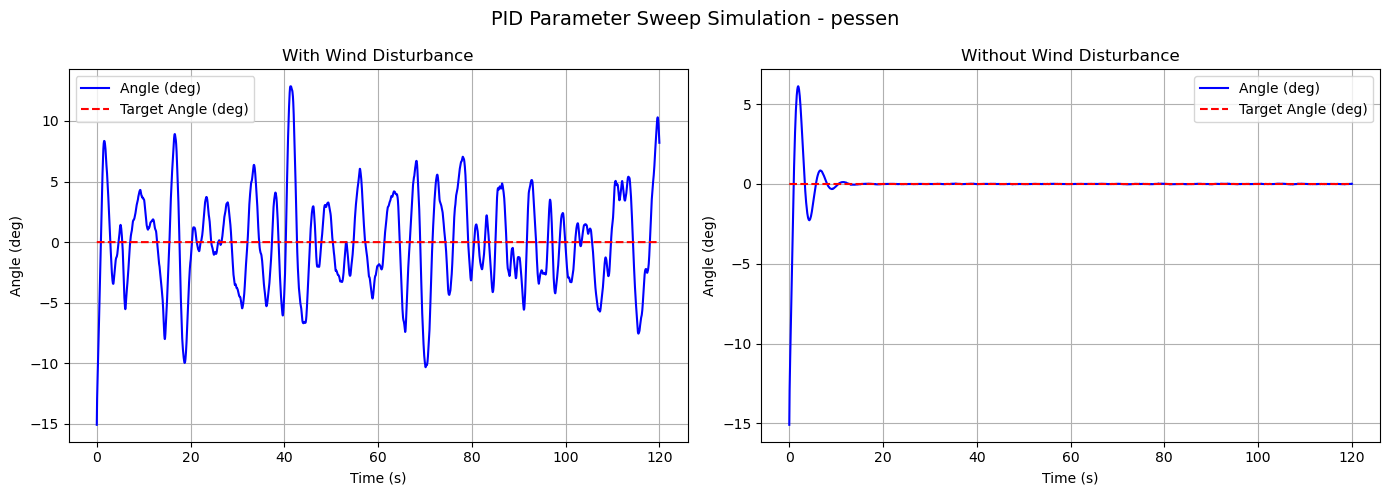

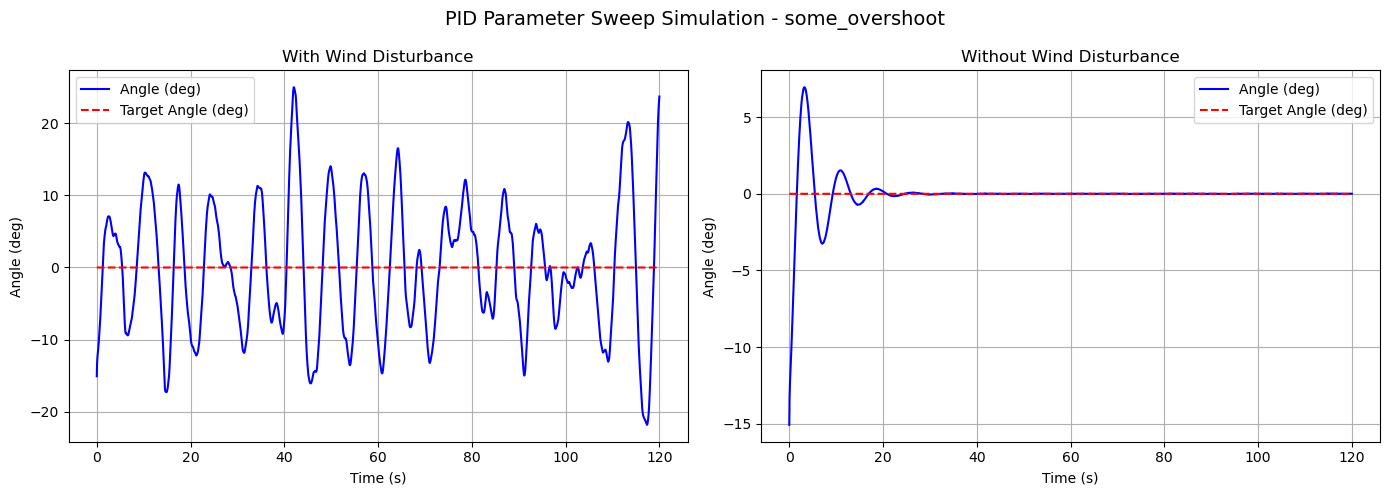

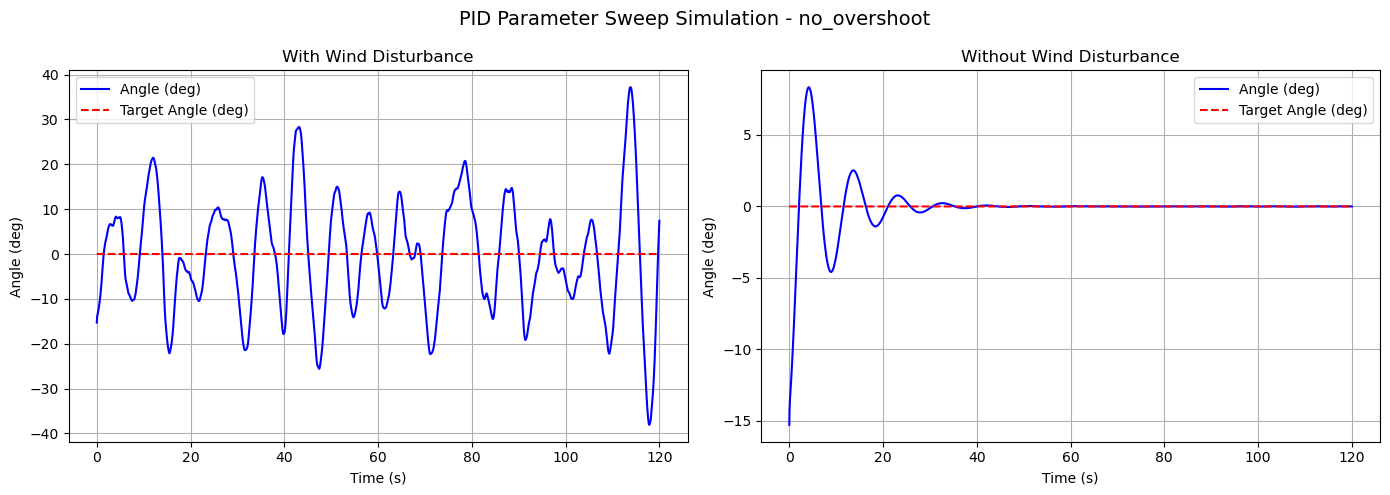

In [47]:
for key, values in sim_result.items():
    fig, (wind_ax, no_wind_ax) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    fig.suptitle(f"PID Parameter Sweep Simulation - {key}", fontsize=14)

    # With Wind Disturbance
    wind_ax.plot(time_history, np.rad2deg(values["wind"]), label="Angle (deg)", color="blue")
    wind_ax.plot(time_history, np.rad2deg(target_history), label="Target Angle (deg)", color="red", linestyle="--")
    wind_ax.set_title("With Wind Disturbance")
    wind_ax.set_xlabel("Time (s)")
    wind_ax.set_ylabel("Angle (deg)")
    wind_ax.legend()
    wind_ax.grid(True)

    # Without Wind Disturbance
    no_wind_ax.plot(time_history, np.rad2deg(values["no_wind"]), label="Angle (deg)", color="blue")
    no_wind_ax.plot(time_history, np.rad2deg(target_history), label="Target Angle (deg)", color="red", linestyle="--")
    no_wind_ax.set_title("Without Wind Disturbance")
    no_wind_ax.set_xlabel("Time (s)")
    no_wind_ax.set_ylabel("Angle (deg)")
    no_wind_ax.legend()
    no_wind_ax.grid(True)

    
    plt.tight_layout()

    save_path = f"simulations/1d_suspended_beam_drone/plots/pid_parameter_sweep_with_and_without_wind_with_angular_damping/pid_sweep_{key}.png"
    save_path = pathlib.Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [52]:
metrics_list = []

for key, values in sim_result.items():
    for mode in sim_mode:
        angle_arr = np.array(np.rad2deg(values[mode]))
        error = angle_arr - target_angle

        rmse = np.sqrt(np.mean(error**2))
        max_deflection = np.max(np.abs(error))
        std_dev = np.std(angle_arr)

        metrics_list.append(
            {
                "Tuning Rule": key,
                "Mode": mode,
                "RMSE (deg)": rmse,
                "Max Deflection (deg)": max_deflection,
                "Std Dev (deg)": std_dev,
            }
        )

df_metrics = pd.DataFrame(metrics_list)

print(
    df_metrics.to_string(
        index=False,
        formatters={
            "RMSE (deg)": "{:.3f}".format,
            "Max Deflection (deg)": "{:.3f}".format,
            "Std Dev (deg)": "{:.3f}".format,
        },
    )
)

   Tuning Rule    Mode RMSE (deg) Max Deflection (deg) Std Dev (deg)
       classic    wind      5.059               15.303         5.059
       classic no_wind      1.050               15.225         1.050
             p    wind     11.288               32.324        11.257
             p no_wind      1.178               15.580         1.166
            pi    wind      7.893               23.042         7.891
            pi no_wind      1.272               15.582         1.272
            pd    wind      7.394               21.843         7.374
            pd no_wind      0.863               15.103         0.856
        pessen    wind      3.990               15.084         3.990
        pessen no_wind      0.959               15.082         0.959
some_overshoot    wind      9.106               24.985         9.104
some_overshoot no_wind      1.357               15.069         1.357
  no_overshoot    wind     12.891               38.086        12.882
  no_overshoot no_wind      1.813 